# Intro

In [1]:
#Exploratory Data Analysis of the melborne ebike trips 2024 dataset 

# Objective
#The goal of this analysis is to understand rider behavior patterns, demand drivers,
#seasonality, and the impact of external factors (temperature and rain) on usage.

#This EDA will:
#- Identify peak usage times
#- Compare subscriber vs casual behavior
#- Analyze station and route demand
#- Explore seasonal and weather effects



In [2]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("../Data/processed/cleaned_data.csv")

In [4]:
df_copy = df.copy()


# Q1 Time analysis

In [5]:
## SET UP 

#setting columns to right dataytype (previously done in cleaning)
df_copy["start_time"]= pd.to_datetime(df_copy["start_time"],format="%Y-%m-%d %H:%M:%S")
df_copy["end_time"]= pd.to_datetime(df_copy["end_time"],format="%Y-%m-%d %H:%M:%S")

#setting up hour column later used for time of day ranges as well as hourly behaviour analysis
df_copy["hour"]= df_copy["start_time"].dt.hour
bins = [0,7,9,12,14,17,19,22,24]

#defining hours ranges 
labels = [
    "late night (12am - 7am) ",
    "morning rush",
    "morning",
    "lunch time",
    "afternoon",
    "evening rush",
    "dinner time",
    "late night (10pm-12am)"
]

#creating time of day collumn
df_copy["time_of_day"] = pd.cut(df_copy["start_time"].dt.hour,bins=bins,labels=labels,right=False)

## 1.1 Analysis into trip duration by time of day

In [ ]:
#grouping data based on time of day and creating a agg function to display a statistics table
grouped_time_of_day =  df_copy.groupby("time_of_day")["trip_duration_min"].agg(

    count = "count",
    avg = "mean",
    std = "std",
    min = "min",
    median ="median",
    max = 'max'

).sort_values(by="count",ascending=False)


grouped_time_of_day=grouped_time_of_day.reset_index()

grouped_time_of_day
#Insight
#As shown per the table below,trip volume is highest during late night (12am -7am) hours (this maybe be due to it being a much larger timeframe than other time groups)
#while expected high trafic hours such as morning rush and evening show comparatively lower ride counts
#Despite fluctuations in demand throughout the day, trip duration remains remarkably consistent across all time periods
# with average rides lasting approximately 14–15 minutes and median durations around 11–12 minutes. This suggests that while the frequency of rides varies by time of day, 
# rider behavior in terms of trip length remains stable, indicating similar usage patterns regardless of when trips occur
# The relatively large standard deviations and high maximum values across all periods also indicate the presence of occasional long-duration outliers 
# These outliers are possibly caused by (sightseeing or leisure rides),but the typical ride appears short and consistent.

,time_of_day,count,avg,std,min,median,max
0,late night (12am - 7am),1477,14.753825,11.875873,0.1,11.80,94.4
1,dinner time,639,14.227074,11.387231,0.4,10.90,77.4
2,afternoon,632,14.747152,10.954282,0.3,12.10,73.5
3,morning,608,14.894408,11.636452,0.4,12.20,90.8
4,lunch time,426,14.139671,10.787042,0.4,11.50,82.2
5,morning rush,421,14.652019,11.234591,0.1,12.20,81.6
6,late night (10pm-12am),403,14.130521,10.472275,0.4,11.70,64.6
7,evening rush,394,15.079949,11.676157,0.1,11.85,80.7


## 1.2 Trip demand by hour analysis 

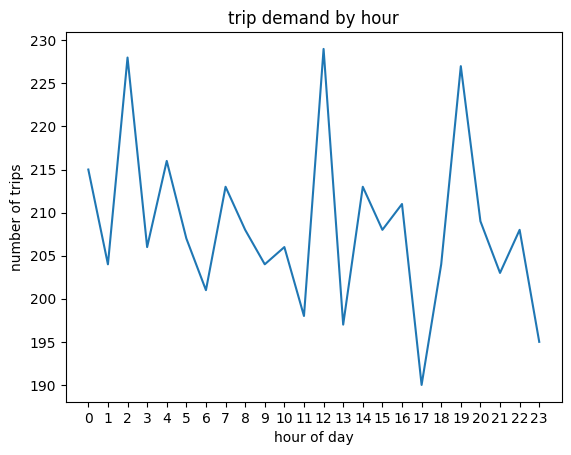

In [78]:
#creating variable to holds how many total trips happend in each hour for the year of 2024
value_counts = df_copy["hour"].value_counts().sort_index()
value_counts2 = df_copy.groupby("hour")["trip_id"].count().reset_index(name="trip count")

#ploting for ease of visualization
value_counts.plot(kind="line")
plt.xlabel("hour of day")
plt.ylabel("number of trips")
plt.title("trip demand by hour")
plt.xticks(range(0,24))
plt.show()

#Insight 
#Ride volume peaks during late night (1–3 AM), lunch time (11 AM–1 PM), and evening rush hours (5–8 PM), indicating multiple distinct usage patterns throughout the day. 
#While late night demand is unexpectedly high, average trip duration remains relatively consistent (as seen in previous table) across all time periods (14–15 minutes)
#suggesting rider behavior does not significantly change by time of day. 
#The presence of both commuter peaks (evening rush) and mid day activity (lunch time) indicates the system supports all kinds of commuters and travel reasons

## 1.3 hourly usage difference Weekday vs weekend ?

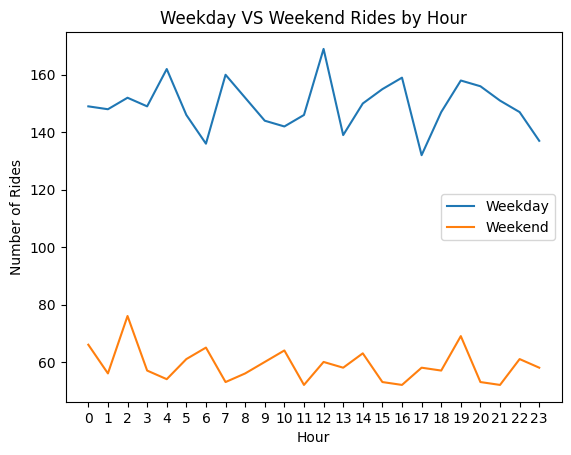

In [31]:
#grouping data based on hour and day type and getting ammount of rides per hour for each day type
grouped_hour_day= df_copy.groupby(["hour","day_type"]).size().unstack(fill_value=0)

#pivot table code
#pivoted_hour_daytype = pd.pivot_table(df_copy,index="hour",columns="day_type",aggfunc="size")
#pivoted_hour_daytype.columns.name = None
#pivoted_hour_daytype
#######

#ploting weekday data from grouped data
grouped_hour_day["Weekday"].plot(kind="line",title="Weekday VS Weekend Rides by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.xticks(range(0,24))

#plotting weekend data from grouped data
grouped_hour_day["Weekend"].plot(kind="line")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.legend()
plt.show()


#Insight
#Weekdays account for the majority of total rides, indicating that overall demand is primarily driven by routine, work-related travel. 
#However, the late-night spike (12 AM–7 AM) is concentrated almost entirely on weekends, 
#confirming that this surge is likely linked to leisure and nightlife activity rather than commuting.
#Weekend demand shows distinct peaks between 1–3 AM and 6–8 PM, while weekday ridership follows a more stable pattern 
#with a modest increase during lunch hours and a slight rise during morning commute times. 
#In contrast, early morning hours and evening rush periods on weekdays exhibit relatively lower activity, 
#suggesting that this system may be used less for traditional end-of-day commuting than expected.


## 1.4 which days of the week have the highest demand ?

In [ ]:
#grouping data by day and counting trip id
grouped_day =df_copy.groupby("day")["trip_id"].count().sort_values(ascending=False)

grouped_day

#insight 
#We see a constitent trip volume trough out the week with a slightly lower volume on wednesday. 
#Slightly lower volumes on weekends suggest reduced work/school related travel but continued recreational use.

# Q2 Station Analysis

## 2.1 Finding most popular start/end station as well as most popular over all station

In [77]:
#both columns are sorted in case of individual analysis

#grouping start and end stations and counting unique values per station
start_s = df_copy.groupby("start_station")["trip_id"].size().sort_values(ascending=False)
end_s = df_copy.groupby("end_station")["trip_id"].size().sort_values(ascending=False)



#printing most popular start and end station
print(f"Most popular start station:",start_s.index[0], "with",start_s.max(),"visits")
print(f"Most popular end station:",end_s.index[0], "with",end_s.max(),"visits")

#including both a comparasion talbe and a total count table 
comp_table = pd.concat([start_s.rename("start_s"),end_s.rename("end_s")],axis=1).reset_index(names="station")

#creating total value column and sorting it 
comp_table["total_count"] = comp_table["start_s"] + comp_table["end_s"]
comp_table.sort_values(by="total_count",ascending=False)

display(comp_table)



#Insight
#Southbank and Fitzroy emerge as the most frequently used stations, with 1,493 and 1,470 trips respectively. 
#However, CBD Central follows closely with 1,447 trips, and the remaining top stations show similarly narrow margins. 
#The relatively small differences between the top locations suggest that demand is distributed across several key stations rather than being concentrated in a single dominant hub. 
#This indicates a well utilized network with multiple high traffic nodes rather than one central station driving the majority of activity.

Most popular start station: Southbank with 789 visits
Most popular end station: Fitzroy with 762 visits


,station,start_s,end_s,total_count
0,Southbank,789,704,1493
1,CBD Central,746,701,1447
2,Richmond,716,715,1431
3,Fitzroy,708,762,1470
4,St Kilda,696,695,1391
5,Carlton,684,733,1417
6,Docklands,661,690,1351


## 2.2 top route deep analysis (same analysis can be done for worst route's)

In [99]:
#creating route column by combining start and end station
df_copy["route"] = df_copy["start_station"].str.strip()+ " -> " + df_copy["end_station"].str.strip()

#creating summary table for every route
route_summary = df_copy.groupby("route").agg(
        trip_count = ("trip_duration_min", "count"),
        
        avg_duration = ("trip_duration_min", "mean"),
        std_duration = ("trip_duration_min", "std"),
        min_duration = ("trip_duration_min", "min"),
        q25_duration = ("trip_duration_min", lambda x: x.quantile(0.25)),
        median_duration = ("trip_duration_min", "median"),
        q75_duration = ("trip_duration_min", lambda x: x.quantile(0.75)),
        max_duration = ("trip_duration_min", "max"),

        avg_distance = ("distance_km", "mean"),
        std_distance = ("distance_km", "std"),
        min_distance = ("distance_km", "min"),
        max_distance = ("distance_km", "max")
    ).sort_values("trip_count", ascending=False)


route_summary = route_summary.reset_index()
route_summary.head()


#Route Performance Insights
#Demand is evenly distributed across the top routes, indicating diversified rider patterns rather than single route dominance.

#Average trip durations are consistent (14–17 min), suggesting relatively stable travel expectations across major routes.

#High variability and extreme max durations indicate presence of outlier trips, likely leisure or delayed docking behavior.

#Distance consistency across routes suggests duration variability is influenced by behavioral or contextual factors rather than route length alone.

#Median duration (11–13 min) is a more reliable central measure than the mean due to skewed distributions.


#Actionable insights
#No route particularly strikes as odd ,all of our top routes have similar behaviours and outliers 

#I would personally monitor the southbank -> richmond route because it has highest avg,standard deviation and highest max 

#Investigate the extreme cases of high duration + low distance , and scan for docking issues/malfunctions, technical issues as well as any 
#misshaps regarding pausing trips without ending 

#Rather than just flagging a specific route do further investigation into outliers by setting up parameters e.g: duration >30m , distance < 1km


,route,trip_count,avg_duration,std_duration,min_duration,q25_duration,median_duration,q75_duration,max_duration,avg_distance,std_distance,min_distance,max_distance
0,Southbank -> Richmond,122,16.670492,14.383081,1.8,6.675,13.00,20.450,94.4,4.302459,3.143252,0.47,17.11
1,Southbank -> Docklands,118,14.379661,11.578351,1.2,6.525,10.95,20.175,81.6,3.840593,2.548263,0.30,15.00
2,Southbank -> St Kilda,118,14.380508,12.235714,0.4,6.100,11.80,17.675,85.7,3.827458,2.611005,0.11,15.30
3,St Kilda -> Fitzroy,117,14.234188,10.854605,1.4,6.200,11.00,18.800,67.7,3.929744,2.497271,0.47,12.90
4,Southbank -> Southbank,116,15.475862,11.996997,0.1,6.600,12.20,21.175,59.6,4.362759,3.273691,0.03,15.10


## 2.3 Finding most popular route by time of day (top5)

In [86]:
#grouping each route by time of day and getting its volume (order of group by will affect pivot table output)
grouped_route_hour_df = df_copy.groupby(["route","time_of_day"]).size()

#pivoting the table using unstack so that  route becomes our rows and time of day our columns (used unstack rather than pivot table so order which we gorup by affects final output)
pivoted_route_hour = grouped_route_hour_df.unstack(fill_value=0)
#creating a total rides column so we can sort based on most popular route
pivoted_route_hour["total_rides"] = pivoted_route_hour.sum(axis=1)

#sorting by ascending order based on total rides
pivoted_route_hour=pivoted_route_hour.sort_values(by="total_rides",ascending=False)
pivoted_route_hour.head()


#insight 
#The table below shows us that most of our popular routes receive peak traffic during the late night hours of 12am to 7am 
#and receive lower but consitent volumes during all other ours of the day
#the worst performing time being the late night hours of 10pm to 12am

time_of_day,late night (12am - 7am),morning rush,morning,lunch time,afternoon,evening rush,dinner time,late night (10pm-12am),total_rides
route,,,,,,,,,
Southbank -> Richmond,33,7,18,11,16,13,17,7,122
Southbank -> Docklands,37,9,10,13,14,9,13,13,118
Southbank -> St Kilda,30,14,22,9,15,6,14,8,118
St Kilda -> Fitzroy,31,14,14,13,13,5,18,9,117
Southbank -> Southbank,40,15,11,8,8,11,14,9,116


# Q3 User Type analysis

## 3.1 user type count and behaviour

In [87]:
#grouping daya by user type and getting volume for each user type 
user_type_count = df_copy.groupby("user_type").size()

#grouping by each user type and creating a statistics table using agg function 
user_and_tripdur = df_copy.groupby("user_type").agg(
        trip_count = ("trip_duration_min", "count"),
        
        avg_duration = ("trip_duration_min", "mean"),
        std_duration = ("trip_duration_min", "std"),
        min_duration = ("trip_duration_min", "min"),
        median_duration = ("trip_duration_min", "median"),
        max_duration = ("trip_duration_min", "max"),

        avg_distance = ("distance_km", "mean"),
        std_distance = ("distance_km", "std"),
        min_distance = ("distance_km", "min"),
        max_distance = ("distance_km", "max")
    ).sort_values("trip_count", ascending=False)



user_type_count
user_and_tripdur.reset_index()
#Insight:
#Subscribers account for the majority of total trips, indicating that the system is primarily driven by recurring users. 
#However, average trip duration and distance remain relatively consistent across both subscriber and casual riders. 
#This suggests that, despite differences in user frequency, overall riding behavior in terms of trip characteristics is similar between the two groups.

,user_type,trip_count,avg_duration,std_duration,min_duration,median_duration,max_duration,avg_distance,std_distance,min_distance,max_distance
0,Subscriber,3250,14.651877,11.631296,0.1,11.6,94.4,3.993237,2.826123,0.03,20.44
1,Casual,1750,14.553143,10.953370,0.1,12.0,89.0,3.964337,2.670327,0.02,16.58


## 3.2 route analysis by user type (top5)

In [ ]:
#grouping route and user type and getitng its volume
route_count_per_user_type = df_copy.groupby(["route","user_type"]).size()

#pivoting using unstack (order of grouping matters)
pivoted_route_count_per_user_type = route_count_per_user_type.unstack(fill_value=0)

#creating a count column for sorting purposes
pivoted_route_count_per_user_type["count"] = pivoted_route_count_per_user_type.sum(axis=1)

#sorting values by most popular route 
pivoted_route_count_per_user_type = pivoted_route_count_per_user_type.sort_values(by="count",ascending=False)

#displaying top 5
pivoted_route_count_per_user_type.head()

#Insight
#Subscribers dominate the most popular routes; however, this largely reflects their higher overall representation in the dataset (approximately 1.5× more frequent than casual users).
#When accounting for this imbalance, there is no clear evidence that user type significantly influences route preference. 
#This suggests that both subscriber and casual riders tend to use similar high-demand corridors within the network.

## 3.3 user type on weekday vs weekend

In [97]:
#grouping day type and user type and getting its volume
grouped_user_daytype = df_copy.groupby(["day_type","user_type"]).size()

grouped_user_daytype.unstack(fill_value=0)

#insight
#Weekday ridership is predominantly driven by subscribers, while weekends show a more balanced distribution between subscribers and casual riders.
#This pattern suggests that subscribers are more active during routine weekday travel, whereas casual usage becomes relatively more prominent on weekends.

#However, given that subscribers represent approximately 1.5× the volume of casual users overall, the apparent weekday dominance should be interpreted with caution.
#When accounting for this baseline imbalance, the difference in weekday activity between user types is less pronounced than raw counts suggest.

user_type,Casual,Subscriber
day_type,,
Weekday,1254,2332
Weekend,496,918


# Q4 Year analysis (per month)

## 4.1 Busiest times of the year + commulative gain/loss table

,trip_id,change,% Change,Cumulative Gain/Loss
month,,,,
1,421,NaN,NaN,NaN
2,397,-24.0,-5.7%,-24.0
3,446,49.0,12.3%,25.0
4,409,-37.0,-8.3%,-12.0
5,415,6.0,1.5%,-6.0
6,410,-5.0,-1.2%,-11.0
7,426,16.0,3.9%,5.0
8,416,-10.0,-2.3%,-5.0
9,432,16.0,3.8%,11.0


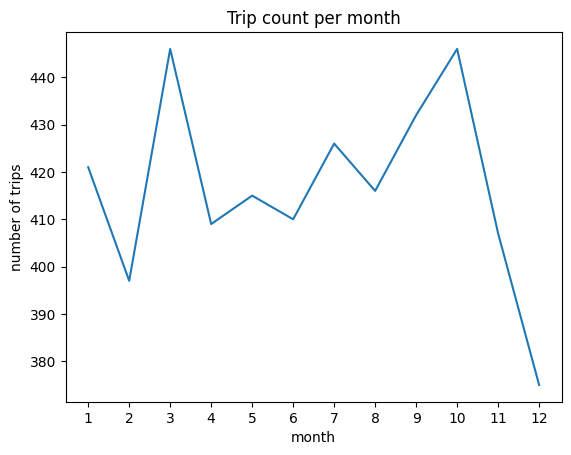

In [ ]:
#Create a monthly summary table

#count total trips in chrono order
trip_count_per_month = df.groupby("month")["trip_id"].count().sort_index()
#turn grouped data to dataframe
trips_per_month_df = trip_count_per_month.to_frame()
#create change column
trips_per_month_df["change"] = trips_per_month_df["trip_id"].diff()
#create % change column
trips_per_month_df["% Change"] = trips_per_month_df["trip_id"].pct_change() * 100
#rounding % change column to one decimal place
trips_per_month_df["% Change"] = trips_per_month_df["% Change"].round(1)
#adding % sign to %change column
trips_per_month_df["% Change"] = trips_per_month_df["% Change"].astype(str) + "%"
#creating comulative gain/loss column
trips_per_month_df["Cumulative Gain/Loss"] = trips_per_month_df["change"].cumsum()

display(trips_per_month_df)


#Plot monthly trip counts to observe seasonality
trip_count_per_month.plot(kind="line",title="Trip count per month")
plt.xticks(range(1,13))
plt.xlabel("month")
plt.ylabel("number of trips")
plt.show()



#Insight:
#Total trip volume declines from 421 trips at the beginning of the year to 375 by year-end, representing a net decrease of 7.9% and a cumulative annual change of -46 trips. 
#It is important to note that this reflects total ride activity rather than unique users, meaning we cannot infer user growth or churn from this metric alone.

#Monthly trends show two distinct demand peaks: one between February and March and another from August through October. 
# In contrast, ridership declines noticeably in January as well as in November and December. 
# These fluctuations suggest the presence of seasonal demand patterns, which may be influenced by external factors such as weather conditions — explored further in subsequent analysis.

## 4.2 Subsriber Ammount troughout the year


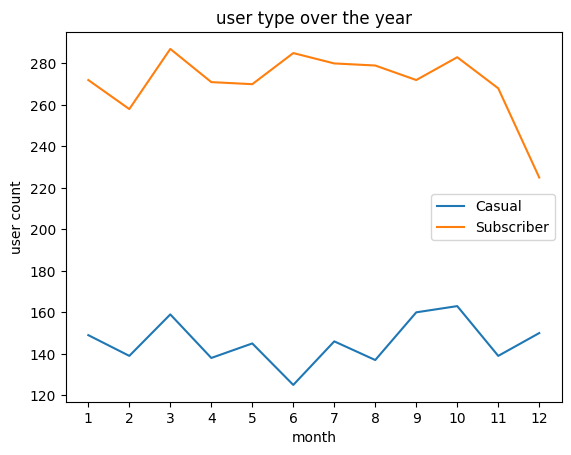

In [ ]:
#grouping user type and month and getting its volume
grouped_month_user = df_copy.groupby(["month","user_type"]).size().unstack(fill_value=0)

#ploting casual user ammont (note as per the group by this will plot per month)
grouped_month_user["Casual"].plot(kind="line",title="user type over the year")
plt.xlabel("Months")
plt.ylabel("user count")


#plotting subsriber ammount
grouped_month_user["Subscriber"].plot(kind="line")
plt.xticks(range(1,13))
plt.legend()
plt.show()



#Insight:
#Subscriber and casual rider volumes follow a broadly similar seasonal pattern throughout the year, indicating that overall demand trends affect both user groups.
#However, two notable divergences appear. During May and June, casual ridership declines while subscriber trips increase. 
#Conversely, in November and December, subscriber trips decrease while casual ridership remains relatively stable.
#This aligns with earlier observations showing a decline in total ridership toward the end of the year, 
#now clarified as being primarily driven by reduced subscriber activity rather than casual usage.

#Hypothesis:
#The late-year decline in subscriber trips may reflect membership cycle effects (e.g., renewals or expirations) or seasonal mobility patterns. 
#Meanwhile, the relative stability in casual usage could indicate short-term or visitor-based demand that is less tied to long-term residency. 
#Further validation would require additional data on membership duration or user location.

# Q5 Bike type analysis

## 5.1 bike tpye deep analysis (statistics table)

In [1]:
bike_summary = df_copy.groupby("bike_type").agg(
        trip_count = ("trip_duration_min", "count"),
        avg_duration = ("trip_duration_min", "mean"),
        std_duration = ("trip_duration_min", "std"),
        min_duration = ("trip_duration_min", "min"),
        median_duration = ("trip_duration_min", "median"),
        max_duration = ("trip_duration_min", "max"),
        avg_distance = ("distance_km", "mean"),
        std_distance = ("distance_km", "std"),
        min_distance = ("distance_km", "min"),
        max_distance = ("distance_km", "max")
    )


bike_summary = bike_summary.reset_index()

bike_summary

#insigth 
# All metrics except trip count are very similar across bike types,
# indicating that bike type does not affect trip duration or distance.
# Electric bikes account for a higher number of trips, suggesting a potential user preference for electrics. 
# However, this could be misleading because,our dataset does not include fleet composition information.
# If the fleet were 50/50 between electric and standard bikes, the data would
# support the conclusion that users prefer electric bikes. If the fleet is
# heavily skewed (e.g., 80% electric), the higher trip count may simply
# reflect availability rather than preference.
#Given these limitations, i wont be looking further into bike type vs hour of day, day of week, route, or user type and call this a dead end    
# any further extra exploration would be speculation and exploratory only

NameError: name 'df_copy' is not defined

# Q6 Exterior factor analysis (temprature analysis)

In [19]:
#How does ride demand change as temperature increases?

#Is there an optimal temperature range for peak demand?

#Does demand drop sharply after a certain temperature threshold?

#How sensitive is ride demand to temperature changes?

## 6.1 how does ride demand change as temperature increases?

In [ ]:
#creating new day of the year column
df_copy['day_of_year'] =  df_copy["start_time"].dt.dayofyear

#grouping by day of year and counting trip ammount for each day
counted_by_day = df_copy.groupby("day_of_year")["trip_id"].count().reset_index(name="trip_count")
#grouping by day of year and counting the average temprature for each day 
daily_temp = df_copy.groupby("day_of_year")["temperature_c"].mean().reset_index(name='avg_temp')

#merging both mean and trip count for each day of the year 
daily_data = pd.merge(counted_by_day, daily_temp, on="day_of_year")

########################################################################################################################################################

#setting up temp ranges (bins and labels)
temp_bins = [-10,-5,0,5,10,15,20,25,30,35,40,45]
labels = ["<5","-5-0","0-5","5-10","10-15","15-20","20-25","25-30","30-35","35-40","40-45",]

#creating new column temp range using bins
df_copy["temp_range"] = pd.cut(df_copy["temperature_c"], bins=temp_bins, labels=labels, include_lowest=True)


#grouping by temp range and using a agg function to get a total number of of temp ranges per day 
#(meaning every day has multiple temp ranges and this will represent the ammount of times each temp range happend per day)
temp_demand = df_copy.groupby("temp_range").agg(
        num_days=("day_of_year", "nunique"),
        total_trips=("trip_id", "count"),
        

    ).reset_index()

#creating a avg rides per day column 
temp_demand["avg_rides_per_day"] = temp_demand["total_trips"] / temp_demand["num_days"]

display(temp_demand.sort_values("avg_rides_per_day", ascending=False))




#Insight
# temperature range shows that rider demand is highest in moderate conditions. 
# The peak average rides per day occur in the 15–20°C range (4.6 rides/day), followed closely by 20–25°C (3.5 rides/day). 
# Usage declines sharply outside this comfort zone: colder temperatures below 10°C and hotter temperatures above 30°C see significantly fewer rides 
# per day. This indicates a clear preference for moderate temperatures, suggesting that rider activity is strongly temperature-dependent. 
# Operationally, these results highlight that most rides occur when temperatures are between 15–25°C, 
# while extreme cold or heat correspond with low ridership.

,temp_range,num_days,total_trips,avg_rides_per_day
5,15-20,360,1658,4.605556
6,20-25,346,1212,3.502890
4,10-15,348,1096,3.149425
7,25-30,268,470,1.753731
3,5-10,231,380,1.645022
8,30-35,87,95,1.091954
2,0-5,62,67,1.080645
0,<5,1,1,1.000000
1,-5-0,6,6,1.000000
9,35-40,15,15,1.000000


## 6.2 Heatmap of trip counts by temperature range and time of day (PURELY EXPLORATORY)

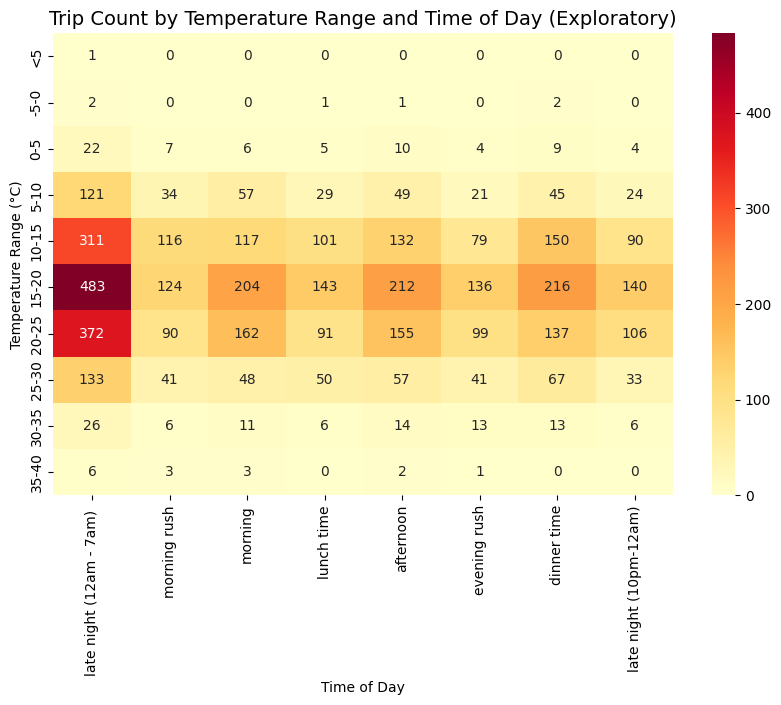

In [ ]:
#grouping by temp range and time of day and counting trip volume
time_temp_summary = df_copy.groupby(["temp_range","time_of_day"]).agg(
        total_trips=("trip_id","count")
        
        ).reset_index()


# Heatmap
pivot_table = time_temp_summary.pivot_table(
    index="temp_range",
    columns="time_of_day",
    values="total_trips",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Trip Count by Temperature Range and Time of Day (Exploratory)", fontsize=14)
plt.xlabel("Time of Day")
plt.ylabel("Temperature Range (°C)")
plt.show()



# Q7 Exterior Factor analysis (rain)

In [96]:
#setting up bins and labels for defining rain category
rain_bins = [-0.1, 0, 2.5, 7.5, 20]  
labels = ["No Rain", "Light Rain 0-2.5mm", "Moderate Rain 2.6-7.5mm", "Heavy Rain 7.5mm+"]

#creating rain category
df_copy["rain_category"] = pd.cut(df_copy["rain_mm"],bins=rain_bins,labels=labels)


raincat_counts=df_copy['rain_category'].value_counts().reset_index()

raincat_counts


,rain_category,count
0,Light Rain 0-2.5mm,3384
1,Moderate Rain 2.6-7.5mm,1540
2,No Rain,69
3,Heavy Rain 7.5mm+,7


## 7.1 normal vs rainy days

In [94]:
grouped_rain_temp = df_copy.groupby(["rain_category","temp_range"]).agg(
    count=("trip_id","count"),

).reset_index()

pivoted_grouped_rain_temp = grouped_rain_temp.pivot_table(
    index="rain_category",
    columns="temp_range",
    values="count",
    aggfunc="sum",
    fill_value=0
)
pivoted_grouped_rain_temp


# Create the bar chart

#insight
#riders overwhelmingly prefer no rain to light rain conditions, particularly in mild temperatures (15–25°C). 
#Trips drop significantly in heavy rain, and very few trips occur at extreme temperatures (<5°C or >30°C), regardless of rain. 
#This suggests that mild weather drives usage more than the absence of rain, and heavy rain is a strong deterrent, especially for casual riders.

temp_range,<5,-5-0,0-5,5-10,10-15,15-20,20-25,25-30,30-35,35-40
rain_category,,,,,,,,,,
No Rain,0,0,1,2,18,17,22,8,1,0
Light Rain 0-2.5mm,1,6,50,262,739,1110,819,322,67,8
Moderate Rain 2.6-7.5mm,0,0,16,116,338,526,370,140,27,7
Heavy Rain 7.5mm+,0,0,0,0,1,5,1,0,0,0


# Key findings Summary

In [24]:
#Key Findings

#There is a presence of both lunch time and leisure/nightlife activity peaks

#Subscribers drive the majority of weekday ridership.

#Usage is strongly seasonal.

#Moderate temperatures (15–25°C) produce highest demand.

#Rain significantly suppresses ridership.

#These patterns suggest that both commuter behavior and weather conditions are primary drivers of system usage

# EXTRA

In [25]:
# EXTRA NOTES 
# Further analysis can include how each varaible relates to one another for example : is the most popular day of the week still the same 
#during holiday times 
#Fleet composition unknown
#No unique user IDs for acquisition/retention analysis